<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo-4-Deep-Leraning/blob/main/4_3_Momentum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementación de Momentum Estándar

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Placeholder for 'data' and 'model' for demonstration purposes.
# In a real scenario, these would be loaded or defined based on your problem.
# Example 'data' for a simple linear regression problem:
# Let's assume data is 2xN where the first row is x values and the second is y values.
data = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    [2.1, 4.2, 5.8, 8.1, 10.3, 12.0, 14.1, 16.2, 18.0, 20.1]
])

# Example 'model' (a simple linear model y = m*x + b, where phi = [m, b])
def model(x, phi):
    return phi[0] * x + phi[1]


In [23]:
# Define compute_loss function
def compute_loss(x, y, model_func, phi):
    predictions = model_func(x, phi)
    return np.mean((predictions - y)**2)


In [24]:
# Define compute_gradient function
def compute_gradient(x, y, phi):
    # For a linear model y = phi[0]*x + phi[1]
    # Loss = (1/N) * sum((phi[0]*x + phi[1] - y)^2)
    # dLoss/d(phi[0]) = (1/N) * sum(2 * (phi[0]*x + phi[1] - y) * x)
    # dLoss/d(phi[1]) = (1/N) * sum(2 * (phi[0]*x + phi[1] - y) * 1)

    predictions = model(x, phi)
    error = predictions - y

    grad_phi0 = np.mean(2 * error * x)
    grad_phi1 = np.mean(2 * error)

    return np.array([[grad_phi0], [grad_phi1]])


In [25]:
# Define draw_model function
def draw_model(data_x_vals, data_y_vals, model_func, phi, title="Model Fit"):
    plt.figure(figsize=(8, 6))
    plt.scatter(data_x_vals, data_y_vals, label='Data points')

    # Generate points for the fitted line
    x_min, x_max = np.min(data_x_vals), np.max(data_x_vals)
    x_vals_for_line = np.linspace(x_min, x_max, 100)
    y_vals_for_line = model_func(x_vals_for_line, phi)
    plt.plot(x_vals_for_line, y_vals_for_line, color='red', label='Fitted model')

    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()

In [26]:
# Define draw_loss_function function
def draw_loss_function(loss_func, data_x, data_y, model_func, phi_all):
    # This function is more complex as it requires visualizing a 2D loss surface.
    # For simplicity, let's just plot the trajectory of phi on a contour plot.
    # A full loss surface plot would involve iterating over a grid of phi values.

    # Assuming phi_all contains the trajectory of parameters [phi0, phi1]
    phi0_trajectory = phi_all[0, :]
    phi1_trajectory = phi_all[1, :]

    # Create a grid for contour plot of the loss function
    phi0_min, phi0_max = np.min(phi0_trajectory) - 1, np.max(phi0_trajectory) + 1
    phi1_min, phi1_max = np.min(phi1_trajectory) - 1, np.max(phi1_trajectory) + 1

    phi0_grid = np.linspace(phi0_min, phi0_max, 50)
    phi1_grid = np.linspace(phi1_min, phi1_max, 50)
    PHI0, PHI1 = np.meshgrid(phi0_grid, phi1_grid)

    LOSS_SURFACE = np.zeros(PHI0.shape)
    for i in range(PHI0.shape[0]):
        for j in range(PHI0.shape[1]):
            current_phi = np.array([[PHI0[i, j]], [PHI1[i, j]]])
            LOSS_SURFACE[i, j] = loss_func(data_x[0], data_x[1], model_func, current_phi)

    plt.figure(figsize=(10, 8))
    plt.contourf(PHI0, PHI1, LOSS_SURFACE, levels=50, cmap='viridis', alpha=0.8)
    plt.colorbar(label='Loss')
    plt.plot(phi0_trajectory, phi1_trajectory, 'r-o', markersize=5, label='Parameter trajectory')
    plt.title('Loss Function Contour with Parameter Trajectory')
    plt.xlabel('phi[0] (Slope)')
    plt.ylabel('phi[1] (Intercept)')
    plt.legend()
    plt.grid(True)
    plt.show()


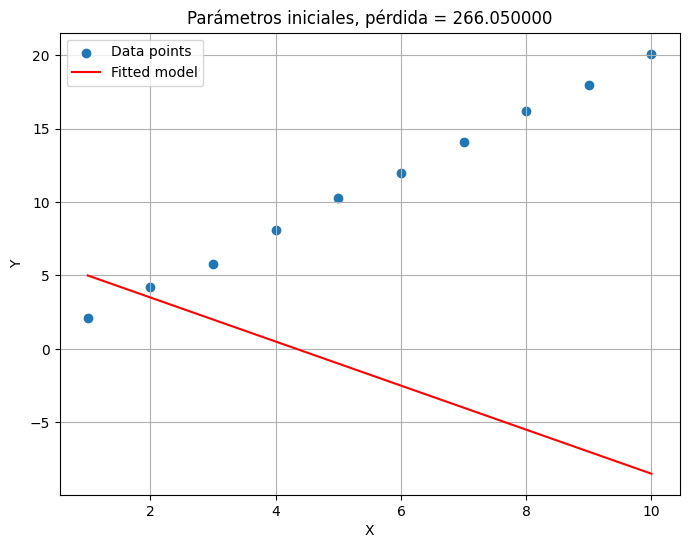

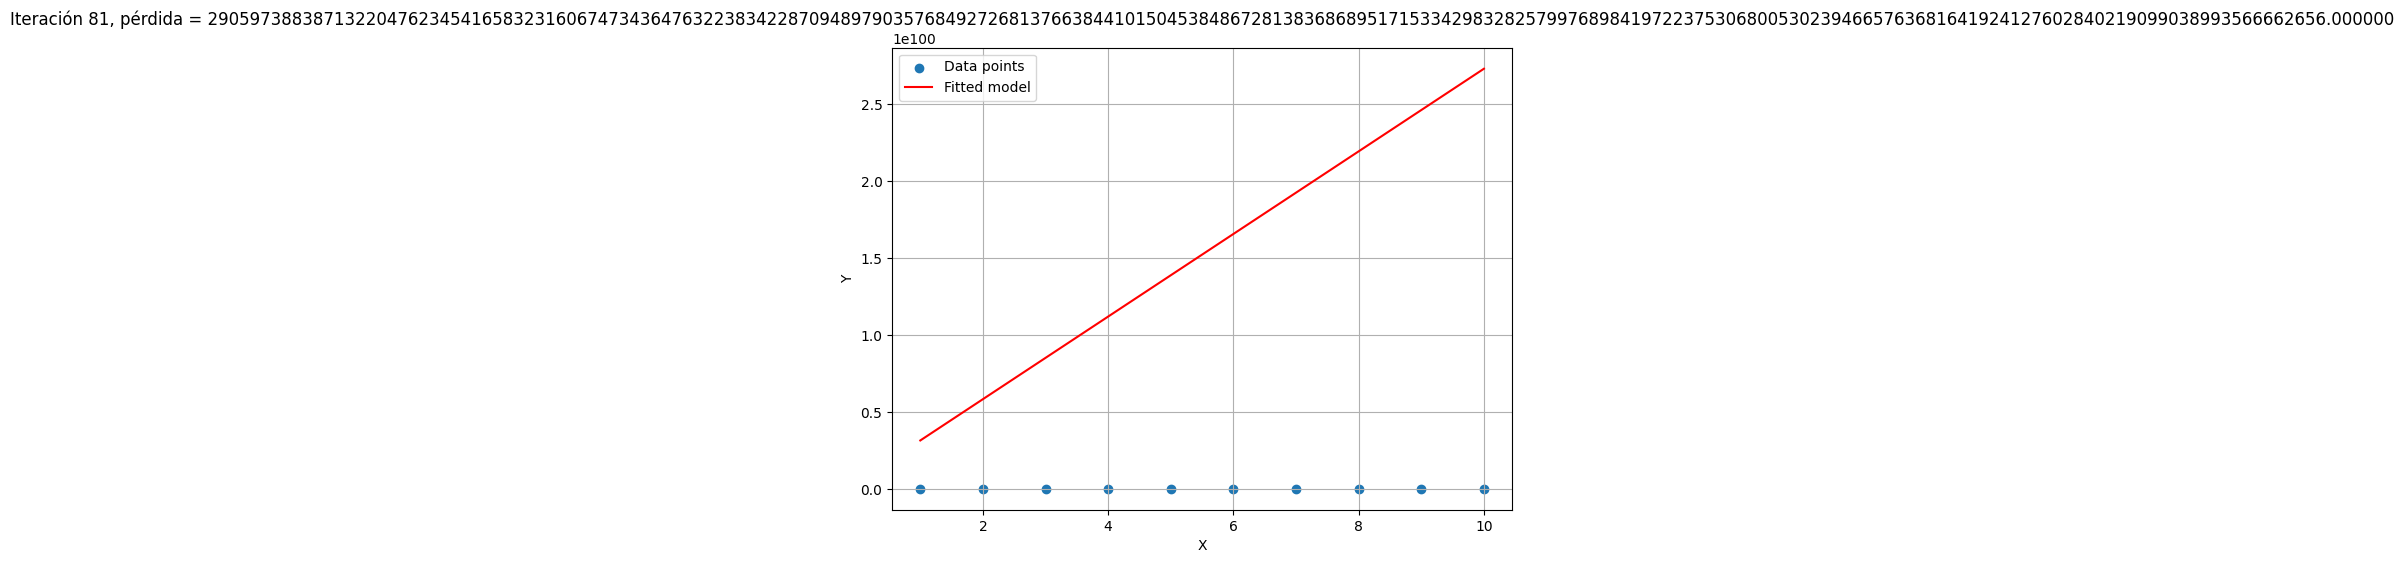

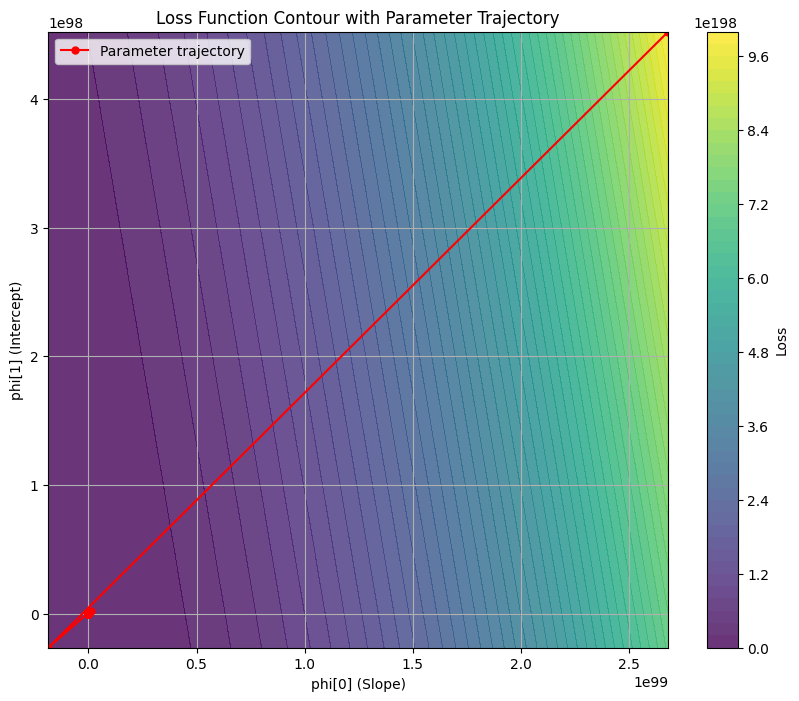

In [27]:
import numpy as np
# Fijar la semilla aleatoria para reproducibilidad
np.random.seed(1)
# Inicializar parámetros
n_steps = 81
batch_size = 5
alpha = 0.6
beta = 0.6
momentum = np.zeros([2,1])
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = -1.5
phi_all[1,0] = 6.5

# Medir la pérdida y dibujar el modelo inicial
loss = compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data[0,:], data[1,:], model, phi_all[:,0:1], "Parámetros iniciales, pérdida = %f"%(loss))

for c_step in range(n_steps):
    # Elegir índices aleatorios del mini-batch
    batch_index = np.random.permutation(data.shape[1])[0:batch_size]
    # Calcular el gradiente
    gradient = compute_gradient(data[0,batch_index], data[1,batch_index], phi_all[:,c_step:c_step+1])

    #  TODO RESUELTO: Calcular Momentum
    momentum = beta * momentum + (1 - beta) * gradient

    # Actualizar los parámetros
    phi_all[:,c_step+1:c_step+2] = phi_all[:,c_step:c_step+1] - alpha * momentum

loss = compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
draw_model(data[0,:], data[1,:], model, phi_all[:,c_step+1], "Iteración %d, pérdida = %f"%(c_step+1,loss))
draw_loss_function(compute_loss, data[0,:], data[1,:], model, phi_all)

Implementación de Momentum de Nesterov

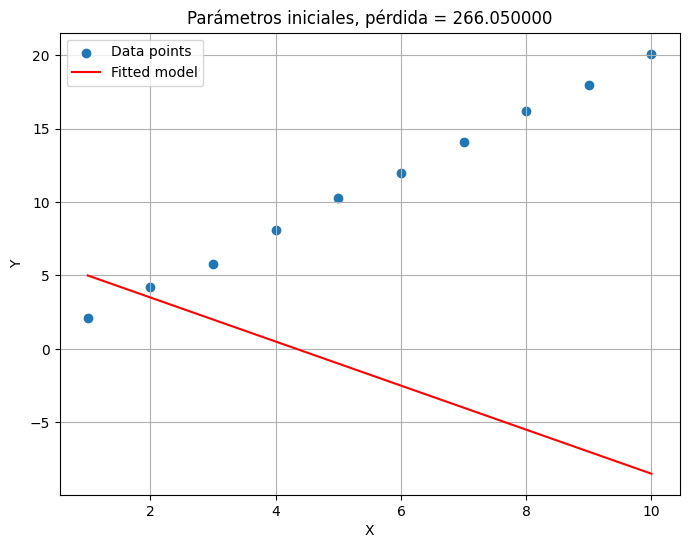

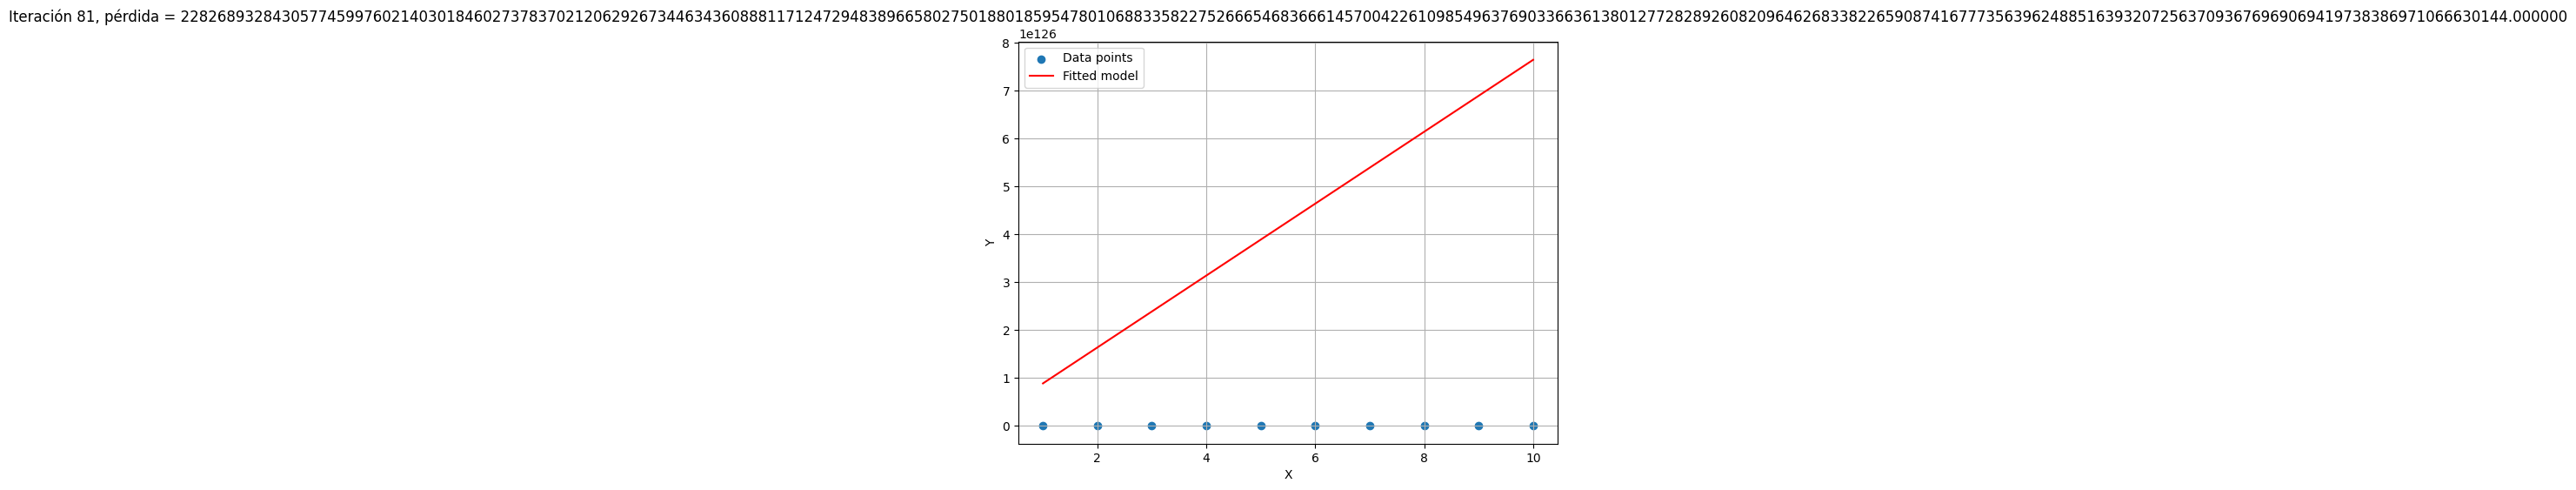

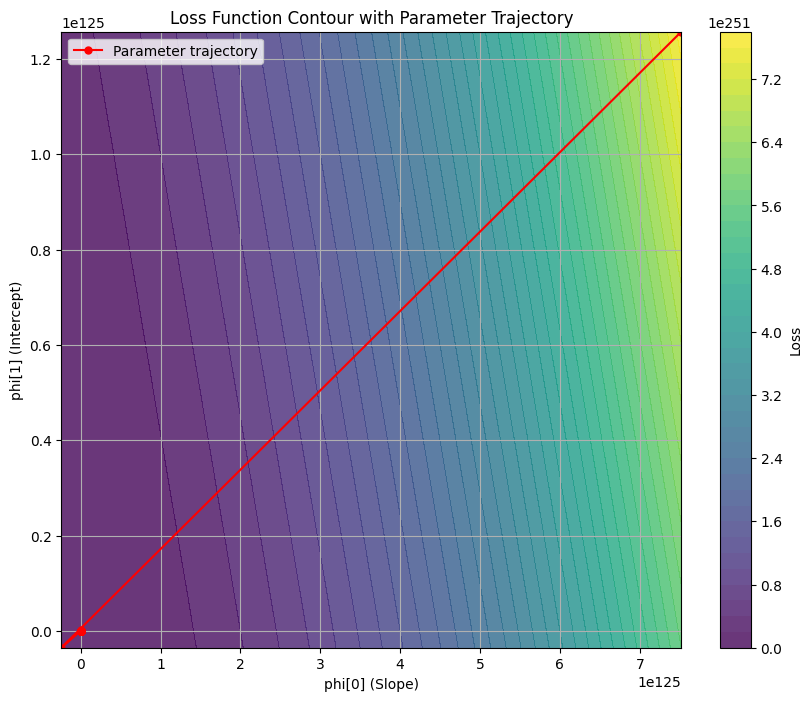

In [28]:
# Fijar la semilla aleatoria para reproducibilidad
np.random.seed(1)
# Inicializar parámetros
n_steps = 81
batch_size = 5
alpha = 0.6
beta = 0.6
momentum = np.zeros([2,1])
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = -1.5
phi_all[1,0] = 6.5

# Medir la pérdida y dibujar el modelo inicial
loss = compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data[0,:], data[1,:], model, phi_all[:,0:1], "Parámetros iniciales, pérdida = %f"%(loss))

for c_step in range(n_steps):
    # Elegir índices aleatorios del mini-batch
    batch_index = np.random.permutation(data.shape[1])[0:batch_size]

    #  TODO RESUELTO: Calcular Momentum de Nesterov
    # Paso 1: Posición adelantada por la velocidad anterior
    phi_ahead = phi_all[:,c_step:c_step+1] - beta * momentum
    # Paso 2: Calcular gradiente en la posición adelantada
    gradient = compute_gradient(data[0,batch_index], data[1,batch_index], phi_ahead)
    # Paso 3: Actualizar velocidad
    momentum = beta * momentum + (1 - beta) * gradient

    # Actualizar los parámetros
    phi_all[:,c_step+1:c_step+2] = phi_all[:,c_step:c_step+1] - alpha * momentum

loss = compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
draw_model(data[0,:], data[1,:], model, phi_all[:,c_step+1], "Iteración %d, pérdida = %f"%(c_step+1,loss))
draw_loss_function(compute_loss, data[0,:], data[1,:], model, phi_all)